# Assignment 1 — VGG16 vs MobileNetV2
## Transfer Learning for Potato Leaf Classification

**Student:** Zehra Nisar

### Objective
This experiment compares two ImageNet-pretrained CNN architectures, **VGG16** and **MobileNetV2**, for binary potato leaf image classification.

The supplied dataset contains two classes:

- **Healthy**
- **Fungi**

The notebook evaluates both models using accuracy, loss, confusion matrices, classification reports, training curves, parameter count, and inference time.

> **Dataset note:** The supplied ZIP contains a very small number of images. Therefore, the numerical results should be interpreted as a small-dataset experiment rather than as a production-quality benchmark.


In [13]:
from google.colab import files
import zipfile
from pathlib import Path

uploaded = files.upload()

Saving Assignment-1-Potato-Package.zip to Assignment-1-Potato-Package (1).zip


In [14]:
import zipfile
from pathlib import Path

zip_name = next(iter(uploaded.keys()))

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("dataset_potato_leaf")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [15]:
!find dataset_potato_leaf -maxdepth 3 -type d

dataset_potato_leaf
dataset_potato_leaf/Assignment-1
dataset_potato_leaf/Assignment-1/dataset_potato_leaf
dataset_potato_leaf/Assignment-1/dataset_potato_leaf/Healthy
dataset_potato_leaf/Assignment-1/dataset_potato_leaf/Fungi
dataset_potato_leaf/Assignment-1/results


In [16]:
# Imports and reproducibility
import os
import random
import shutil
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 4
EPOCHS = 10
CLASS_NAMES = ["Fungi", "Healthy"]

DATA_DIR = "dataset_potato_leaf"
WORK_DIR = "prepared_potato_dataset"
RESULTS_DIR = "results"

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Classes:", CLASS_NAMES)


TensorFlow version: 2.20.0
Classes: ['Fungi', 'Healthy']


In [19]:
!find dataset_potato_leaf -maxdepth 3 -type d

dataset_potato_leaf
dataset_potato_leaf/Assignment-1
dataset_potato_leaf/Assignment-1/dataset_potato_leaf
dataset_potato_leaf/Assignment-1/dataset_potato_leaf/Healthy
dataset_potato_leaf/Assignment-1/dataset_potato_leaf/Fungi
dataset_potato_leaf/Assignment-1/results


## 1. Dataset Preparation

The uploaded dataset is organized by class folders. This section creates reproducible **train, validation, and test** splits.

Because the supplied dataset is small, the split is intentionally kept simple and the notebook reports the number of images used in each subset.


In [22]:
# Check Potato Leaf dataset structure

from pathlib import Path

# Actual dataset location in Google Colab
DATA_DIR = "dataset_potato_leaf/Assignment-1/dataset_potato_leaf"

source = Path(DATA_DIR)

if not source.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {source.resolve()}\n"
        "Make sure the dataset has been extracted correctly."
    )

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for class_name in CLASS_NAMES:
    class_path = source / class_name

    if not class_path.exists():
        raise FileNotFoundError(
            f"Missing class folder: {class_path}"
        )

    n = sum(
        1
        for p in class_path.rglob("*")
        if p.is_file() and p.suffix.lower() in image_exts
    )

    print(f"{class_name}: {n} image(s)")

Fungi: 6 image(s)
Healthy: 14 image(s)


In [29]:
from pathlib import Path
import shutil
import random

# Actual source dataset
source = Path(DATA_DIR)

# New prepared dataset
WORK_DIR = Path("prepared_potato_dataset")

# Remove old incorrect split, if it exists
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

train_dir = WORK_DIR / "train"
val_dir = WORK_DIR / "val"
test_dir = WORK_DIR / "test"

for folder in [train_dir, val_dir, test_dir]:
    for class_name in CLASS_NAMES:
        (folder / class_name).mkdir(parents=True, exist_ok=True)

random.seed(SEED)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Split each class
for class_name in CLASS_NAMES:
    class_source = source / class_name

    images = [
        p for p in class_source.rglob("*")
        if p.is_file() and p.suffix.lower() in image_exts
    ]

    random.shuffle(images)

    n = len(images)

    # 60% train, 20% validation, 20% test
    n_train = max(1, int(n * 0.6))
    n_val = max(1, int(n * 0.2))

    # Make sure at least one image remains for test
    if n_train + n_val >= n:
        n_train = max(1, n - 2)
        n_val = 1

    train_images = images[:n_train]
    val_images = images[n_train:n_train + n_val]
    test_images = images[n_train + n_val:]

    for img in train_images:
        shutil.copy2(img, train_dir / class_name / img.name)

    for img in val_images:
        shutil.copy2(img, val_dir / class_name / img.name)

    for img in test_images:
        shutil.copy2(img, test_dir / class_name / img.name)

    print(
        f"{class_name}: "
        f"{len(train_images)} train, "
        f"{len(val_images)} validation, "
        f"{len(test_images)} test"
    )

print("\nDataset split completed.")

Fungi: 3 train, 1 validation, 2 test
Healthy: 8 train, 2 validation, 4 test

Dataset split completed.


## 2. Data Generators

Images are resized to **224 × 224** and normalized to the `[0, 1]` range.

The same preprocessing setup is used for both models to make the comparison consistent.


In [30]:
train_datagen = ImageDataGenerator(rescale=1./255)
eval_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    Path(WORK_DIR) / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_gen = eval_datagen.flow_from_directory(
    Path(WORK_DIR) / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    Path(WORK_DIR) / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class mapping:", train_gen.class_indices)


Found 11 images belonging to 2 classes.
Found 3 images belonging to 2 classes.
Found 6 images belonging to 2 classes.
Class mapping: {'Fungi': 0, 'Healthy': 1}


## 3. Transfer Learning Model Builder

A common classification head is placed on top of each ImageNet-pretrained feature extractor:

`Global Average Pooling → Dense(128) → Dropout → Sigmoid`

The convolutional base is frozen during initial training.


In [31]:
def build_transfer_model(base_model):
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.30)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

mobile_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

vgg_model = build_transfer_model(vgg_base)
mobile_model = build_transfer_model(mobile_base)

print("VGG16 parameters:", f"{vgg_model.count_params():,}")
print("MobileNetV2 parameters:", f"{mobile_model.count_params():,}")


VGG16 parameters: 14,780,481
MobileNetV2 parameters: 2,422,081


## 4. Train VGG16

In [32]:
print("Train samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)
print("Test samples:", test_gen.samples)

print("Train batches:", len(train_gen))
print("Validation batches:", len(val_gen))
print("Test batches:", len(test_gen))

Train samples: 11
Validation samples: 3
Test samples: 6
Train batches: 3
Validation batches: 1
Test batches: 2


In [33]:
vgg_history = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.2727 - loss: 0.8909 - val_accuracy: 0.3333 - val_loss: 0.7585
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.4545 - loss: 0.8501 - val_accuracy: 0.3333 - val_loss: 0.7238
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.4545 - loss: 0.7931 - val_accuracy: 0.6667 - val_loss: 0.6925
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.6364 - loss: 0.6417 - val_accuracy: 0.6667 - val_loss: 0.6709
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4545 - loss: 0.7489 - val_accuracy: 0.6667 - val_loss: 0.6532
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.4545 - loss: 0.6899 - val_accuracy: 0.6667 - val_loss: 0.6403
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.7273 - loss: 0.5970 - val_accuracy: 0.6667 - val_loss: 0.6308
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.7273 - loss: 0.5570 - val_accuracy: 0.6667 - val_loss: 0.6243
Epoch 9/10


## 5. Train MobileNetV2

In [34]:
mobile_history = mobile_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6364 - loss: 0.6011 - val_accuracy: 0.6667 - val_loss: 0.7525
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.6364 - loss: 0.5996 - val_accuracy: 0.6667 - val_loss: 0.7735
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 0.7273 - loss: 0.5097 - val_accuracy: 0.6667 - val_loss: 0.7952
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.7273 - loss: 0.4022 - val_accuracy: 0.6667 - val_loss: 0.8055
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.7273 - loss: 0.4037 - val_accuracy: 0.6667 - val_loss: 0.8022
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.9091 - loss: 0.3013 - val_accuracy: 0.6667 - val_loss: 0.7875
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.9091 - loss: 0.2646 - val_accuracy: 0.6667 - val_loss: 0.7818
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step - accuracy: 0.8182 - loss: 0.3643 - val_accuracy: 0.6667 - val_loss: 0.

## 6. Model Evaluation

The evaluation section reports test loss and accuracy, followed by class-level metrics.


In [35]:
def evaluate_model(model, name):
    test_gen.reset()
    loss, accuracy = model.evaluate(test_gen, verbose=0)

    test_gen.reset()
    probabilities = model.predict(test_gen, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    true_labels = test_gen.classes

    cm = confusion_matrix(true_labels, predictions, labels=[0, 1])
    report = classification_report(
        true_labels,
        predictions,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(f"\n{name}")
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)

    return {
        "loss": float(loss),
        "accuracy": float(accuracy),
        "cm": cm,
        "predictions": predictions,
        "true_labels": true_labels
    }

vgg_results = evaluate_model(vgg_model, "VGG16")
mobile_results = evaluate_model(mobile_model, "MobileNetV2")



VGG16
Test Loss: 0.6515
Test Accuracy: 0.6667

Classification Report:
              precision    recall  f1-score   support

       Fungi       0.00      0.00      0.00         2
     Healthy       0.67      1.00      0.80         4

    accuracy                           0.67         6
   macro avg       0.33      0.50      0.40         6
weighted avg       0.44      0.67      0.53         6


MobileNetV2
Test Loss: 0.7337
Test Accuracy: 0.6667

Classification Report:
              precision    recall  f1-score   support

       Fungi       0.00      0.00      0.00         2
     Healthy       0.67      1.00      0.80         4

    accuracy                           0.67         6
   macro avg       0.33      0.50      0.40         6
weighted avg       0.44      0.67      0.53         6



## 7. Confusion Matrices

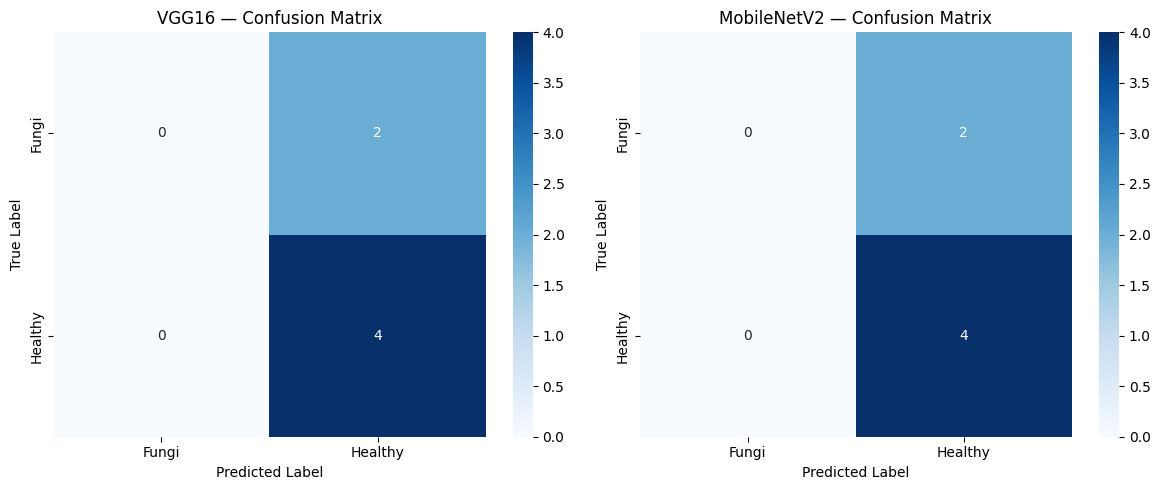

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, result, title in zip(
    axes,
    [vgg_results, mobile_results],
    ["VGG16", "MobileNetV2"]
):
    sns.heatmap(
        result["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig(Path(RESULTS_DIR) / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. Training Curves

Training and validation curves are plotted to inspect learning behaviour and possible overfitting.


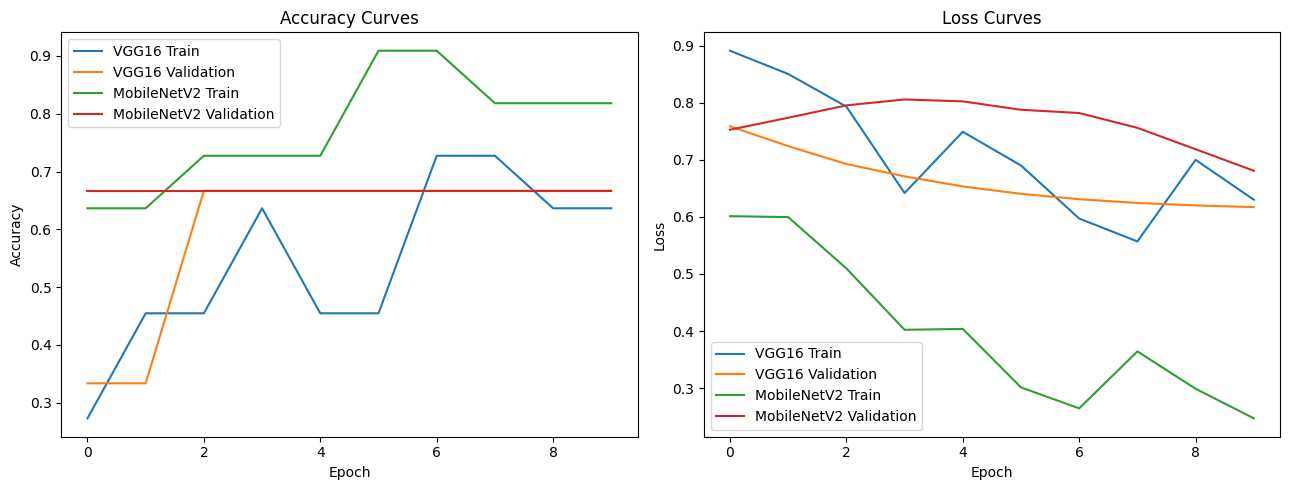

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(vgg_history.history["accuracy"], label="VGG16 Train")
axes[0].plot(vgg_history.history["val_accuracy"], label="VGG16 Validation")
axes[0].plot(mobile_history.history["accuracy"], label="MobileNetV2 Train")
axes[0].plot(mobile_history.history["val_accuracy"], label="MobileNetV2 Validation")
axes[0].set_title("Accuracy Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(vgg_history.history["loss"], label="VGG16 Train")
axes[1].plot(vgg_history.history["val_loss"], label="VGG16 Validation")
axes[1].plot(mobile_history.history["loss"], label="MobileNetV2 Train")
axes[1].plot(mobile_history.history["val_loss"], label="MobileNetV2 Validation")
axes[1].set_title("Loss Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(Path(RESULTS_DIR) / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Model Efficiency Comparison

Besides classification performance, the experiment measures model parameter count and a simple inference-time estimate.


In [39]:
def measure_inference(model, generator, repeats=3):
    generator.reset()

    # Warm-up
    x, _ = next(generator)
    _ = model.predict(x, verbose=0)

    times = []
    for _ in range(repeats):
        generator.reset()
        x, _ = next(generator)
        start = time.perf_counter()
        _ = model.predict(x, verbose=0)
        times.append(time.perf_counter() - start)

    return float(np.mean(times))

vgg_time = measure_inference(vgg_model, test_gen)
mobile_time = measure_inference(mobile_model, test_gen)

comparison = {
    "VGG16": {
        "accuracy": vgg_results["accuracy"],
        "loss": vgg_results["loss"],
        "parameters": vgg_model.count_params(),
        "inference_seconds": vgg_time
    },
    "MobileNetV2": {
        "accuracy": mobile_results["accuracy"],
        "loss": mobile_results["loss"],
        "parameters": mobile_model.count_params(),
        "inference_seconds": mobile_time
    }
}

print("\nFinal comparison:")
for model_name, values in comparison.items():
    print(f"\n{model_name}")
    print(f"  Accuracy: {values['accuracy']:.4f}")
    print(f"  Loss: {values['loss']:.4f}")
    print(f"  Parameters: {values['parameters']:,}")
    print(f"  Inference time: {values['inference_seconds']:.4f} sec")



Final comparison:

VGG16
  Accuracy: 0.6667
  Loss: 0.6515
  Parameters: 14,780,481
  Inference time: 2.7013 sec

MobileNetV2
  Accuracy: 0.6667
  Loss: 0.7337
  Parameters: 2,422,081
  Inference time: 0.1999 sec


# 📊 Final Analysis

### Accuracy
The test accuracy indicates how well each architecture classifies unseen potato leaf images.

### Loss
Lower test loss generally indicates better agreement between predictions and true labels.

### Confusion Matrix
The confusion matrices show class-specific errors and help identify whether one class is being confused with the other.

### Training Curves
The relationship between training and validation curves can reveal whether the model is learning consistently or overfitting.

### Efficiency
Parameter count and inference time provide an additional practical comparison. MobileNetV2 is designed as a lightweight architecture, whereas VGG16 is substantially larger.

> **Important:** Because the supplied dataset is very small, the observed metrics can vary substantially and should not be treated as a general performance estimate for potato disease detection.

## Conclusion

This experiment demonstrates transfer learning with two different CNN architectures. VGG16 provides a strong, larger baseline, while MobileNetV2 offers a more efficiency-oriented alternative. The final model choice should consider the measured classification results together with computational cost and the limitations of the small dataset.
